# CADS lesion benchmark (Colab GPU)
3D Faster R-CNN vs batched per-slice classifier — memory + time.

Pipeline: **data → data analysis → train both tracks → test both on held-out scans (quality) → benchmark both on those scans (latency + memory)**.
Small real subset, minimal training. Run top-to-bottom on a T4/L4.

Tip: upload the `modiface` folder to Google Drive once (Option B below) — code and `checkpoints/` then persist across sessions. Bulk NIfTI data goes to local Colab SSD (`DATA_ROOT`, section 0): Drive's FUSE mount drops under heavy I/O, while local disk is fast and reliable (re-download each session; it's quick).

In [43]:
!nvidia-smi
!pip -q install torch torchvision --index-url https://download.pytorch.org/whl/cu121
!pip -q install nibabel huggingface_hub datasets pyyaml tqdm scikit-learn psutil matplotlib

Sun Oct  4 05:14:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 0. Project code & paths — pick ONE option
Run **either** Option A (GitHub) **or** Option B (Google Drive), then the path check.

In [44]:
# ── Option A: clone from GitHub ──
!git clone https://github.com/adoskk/MachineLearningBasics.git
%cd MachineLearningBasics/CV/CNN_vs_3DRCNN_latency

fatal: destination path 'MachineLearningBasics' already exists and is not an empty directory.
/content/drive/MyDrive/Colab Notebooks/modiface/MachineLearningBasics/CV/CNN_vs_3DRCNN_latency


In [45]:
# ── Option B: use the project folder you uploaded to Google Drive ──
# 1. In Drive, upload the CNN_vs_3DRCNN_latency folder (code only, no data/),
#    e.g. MyDrive/Colab Notebooks/CNN_vs_3DRCNN_latency
#    (bulk data goes to local SSD in section 0)
# 2. Set DRIVE_PROJECT below to that location, then run this cell
DRIVE_PROJECT = 'MyDrive/Colab Notebooks/modiface'  # <-- edit if elsewhere

import os
from google.colab import drive
drive.mount('/content/drive')
PROJECT_ROOT = f'/content/drive/{DRIVE_PROJECT}'
os.chdir(PROJECT_ROOT)
print('cwd:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cwd: /content/drive/MyDrive/Colab Notebooks/modiface


In [46]:
# ── Path check: CWD == project root; bulk DATA on local SSD ──
# Drive FUSE disconnects under heavy I/O ('Transport endpoint is not
# connected'), so NIfTI data lives on ephemeral /content (fast, reliable)
# while code + checkpoints stay on Drive (persistent).
import os
assert os.path.exists('configs/config.yaml'), 'not in project root — run Option A or B first'
DATA_ROOT = '/content/drive/MyDrive/Colab Notebooks/modiface/data/cads'
os.makedirs(DATA_ROOT, exist_ok=True)
for d in ['checkpoints', 'results']:
    os.makedirs(d, exist_ok=True)
print('project root OK:', os.getcwd())
print('DATA_ROOT (local SSD):', DATA_ROOT)
!ls

project root OK: /content/drive/MyDrive/Colab Notebooks/modiface
DATA_ROOT (local SSD): /content/drive/MyDrive/Colab Notebooks/modiface/data/cads
checkpoints  data		    MyDrive    README.md	 results  src
configs      MachineLearningBasics  notebooks  requirements.txt  scripts  tests


## 1. Data — local SSD, re-download each session
Accept the terms at https://huggingface.co/datasets/mrmrx/CADS-dataset. Download targets `DATA_ROOT` (/content, fast local disk) and is skipped if volumes are already there. `--max-files` caps total NIfTI files (whole volumes: 1 image + one file per `--parts`); e.g. `120` = ~60 part-551 volumes, plenty for the default `n_volumes: 30`.

Drive disconnected? (`Transport endpoint is not connected`) — remount and resume from Option B:
`drive.mount('/content/drive', force_remount=True)`

In [47]:
import subprocess
from pathlib import Path

cached = list(Path(DATA_ROOT).rglob('images/*.nii*'))
print('cached volumes:', len(cached))
if cached:
    print(f'using cached data in {DATA_ROOT} — rm -rf it to re-download')
else:
    from huggingface_hub import login
    login()  # paste token
    subprocess.run(['python', 'scripts/download_subset.py',
                      '--subsets', '0003_kits21', '0004_lits',
                      '--local-dir', DATA_ROOT,
                      '--max-files', '5000',
                      '--parts', '551'], check=True)

cached volumes: 1503
using cached data in /content/drive/MyDrive/Colab Notebooks/modiface/data/cads — rm -rf it to re-download


## 2. Data analysis — what are we training on?
Volumes per split, native resolution (x/y/z) and spacing spread, target-object sizes and where they sit in the scan. Saves figures + `results/data_analysis_summary.json`.

### Target-mask configuration

The analysis and both models use the same target masks:

- `seg_parts=[551]` selects CADS specialist **part 551**, which contains abdominal-organ labels.
- `0003_kits21: [2, 3]` keeps label 2 (right kidney) and label 3 (left kidney).
- `0004_lits: [5]` keeps label 5 (liver).
- All other labels are treated as background.

Therefore, the current task is an **organ-localization proxy**, not true tumor/lesion detection: the detector predicts kidney/liver boxes, while the slice classifier predicts whether a slice contains the corresponding organ.

### Reading the native-grid boxplots

For each D/H/W dimension, the center line is the **median**; the box spans **Q1–Q3** (25th–75th percentiles, the middle 50%); whiskers extend to the farthest observations within **1.5 × IQR**; points beyond them are outliers. The whiskers equal the true minimum and maximum only when there are no values beyond the 1.5 × IQR limits.

[eda] modiface v0.9.0 | cwd=/content/drive/MyDrive/Colab Notebooks/modiface
[data] root=/content/drive/MyDrive/Colab Notebooks/modiface/data/cads
[data] seg parts=[551] labels={'0003_kits21': [2, 3], '0004_lits': [5]}
[data] real cohort: 30 volumes
[data] split train/val/test = 24/3/3
[eda] native fallback to resized for LITS_volume-76_0000: int64 should be floating point type
[eda] native fallback to resized for KITScase_00132_0000: int64 should be floating point type
[eda] native fallback to resized for LITS_volume-75_0000: int64 should be floating point type
[eda] native fallback to resized for KITScase_00046_0000: int64 should be floating point type
[eda] native fallback to resized for KITScase_00040_0000: int64 should be floating point type
[eda] native fallback to resized for KITScase_00232_0000: int64 should be floating point type
[eda] native fallback to resized for KITScase_00045_0000: int64 should be floating point type
[eda] native fallback to resized for LITS_volume-35_0000

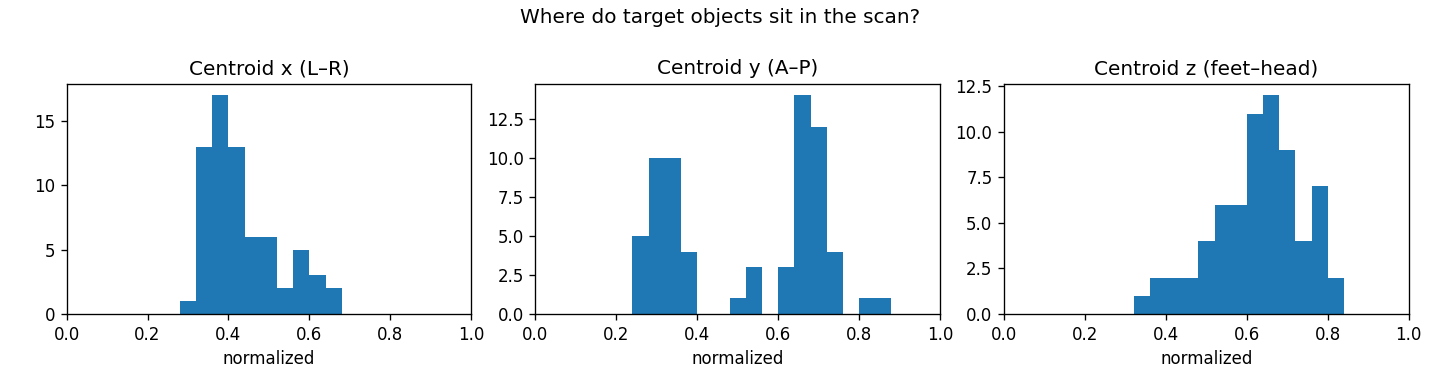

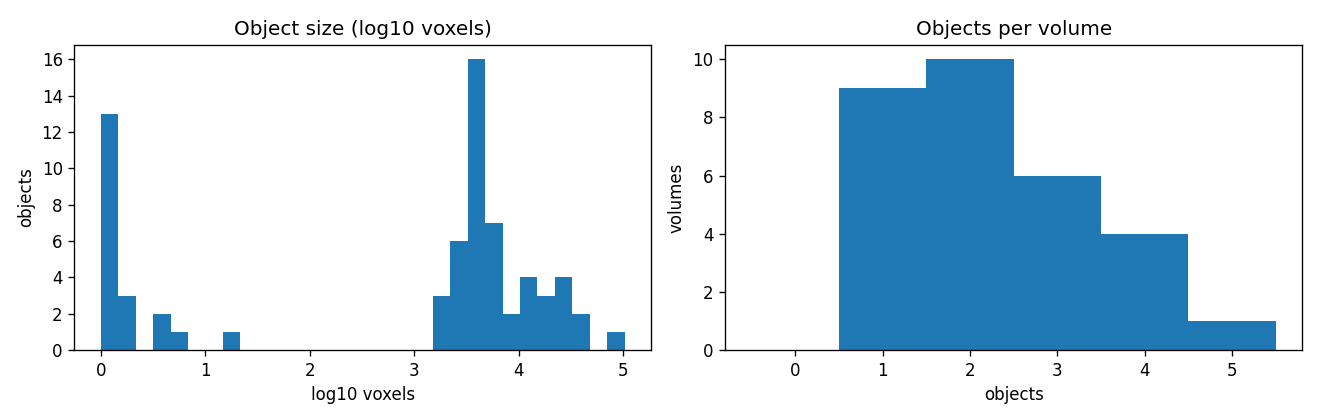

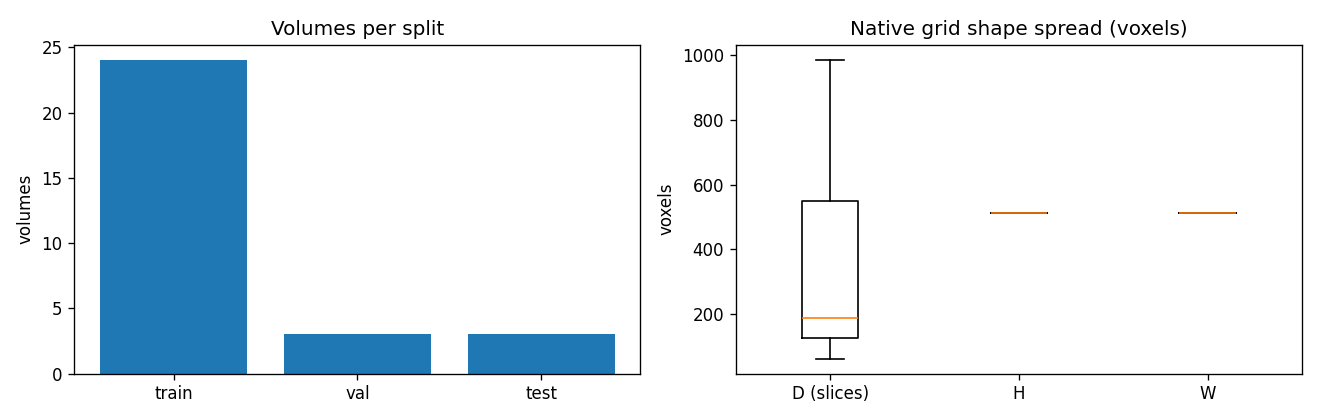

In [48]:
!python scripts/analyze_data.py --config configs/config.yaml --data-root "/content/drive/MyDrive/Colab Notebooks/modiface/data/cads" --out results

from pathlib import Path
from IPython.display import Image, display
for f in sorted(Path('results').glob('eda_*.png')):
    display(Image(str(f)))

## 3. Train both tracks
One script per model — revisit either one independently (`src/detector/`, `src/classifier/`). Checkpoints land in `checkpoints/`.

In [49]:
%%time
!python scripts/train_detector.py --config configs/config.yaml --data-root "/content/drive/MyDrive/Colab Notebooks/modiface/data/cads"

[train-det] modiface v0.9.0 | cwd=/content/drive/MyDrive/Colab Notebooks/modiface
[train-det] device=cuda
[data] root=/content/drive/MyDrive/Colab Notebooks/modiface/data/cads
[data] seg parts=[551] labels={'0003_kits21': [2, 3], '0004_lits': [5]}
[data] real cohort: 30 volumes
[data] split train/val/test = 24/3/3
det ep1: 100% 24/24 [00:18<00:00,  1.30it/s]
[det] epoch 1 loss=0.4856
det ep2: 100% 24/24 [00:15<00:00,  1.54it/s]
[det] epoch 2 loss=0.3806
det ep3: 100% 24/24 [00:16<00:00,  1.50it/s]
[det] epoch 3 loss=0.2727
det ep4: 100% 24/24 [00:16<00:00,  1.47it/s]
[det] epoch 4 loss=0.0785
det ep5: 100% 24/24 [00:16<00:00,  1.45it/s]
[det] epoch 5 loss=0.2340
CPU times: user 520 ms, sys: 63 ms, total: 583 ms
Wall time: 4min 7s


In [50]:
%%time
!python scripts/train_classifier.py --config configs/config.yaml --data-root "/content/drive/MyDrive/Colab Notebooks/modiface/data/cads"

[train-cls] modiface v0.9.0 | cwd=/content/drive/MyDrive/Colab Notebooks/modiface
[train-cls] device=cuda
[data] root=/content/drive/MyDrive/Colab Notebooks/modiface/data/cads
[data] seg parts=[551] labels={'0003_kits21': [2, 3], '0004_lits': [5]}
[data] real cohort: 30 volumes
[data] split train/val/test = 24/3/3
cls ep1: 100% 48/48 [00:04<00:00, 10.90it/s]
[cls] epoch 1 loss=0.0109
cls ep2: 100% 48/48 [00:01<00:00, 27.52it/s]
[cls] epoch 2 loss=0.0048
cls ep3: 100% 48/48 [00:01<00:00, 27.43it/s]
[cls] epoch 3 loss=0.0038
cls ep4: 100% 48/48 [00:01<00:00, 27.16it/s]
[cls] epoch 4 loss=0.0034
cls ep5: 100% 48/48 [00:01<00:00, 26.95it/s]
[cls] epoch 5 loss=0.0026
CPU times: user 388 ms, sys: 54.6 ms, total: 443 ms
Wall time: 3min 2s


## 4. Test both on the held-out scans (quality)
Detector: AP@IoU3D. Classifier: slice AP / AUROC. Untimed — pure quality context for the benchmark.

In [51]:
!python scripts/test_detector.py --config configs/config.yaml --data-root "/content/drive/MyDrive/Colab Notebooks/modiface/data/cads"
!python scripts/test_classifier.py --config configs/config.yaml --data-root "/content/drive/MyDrive/Colab Notebooks/modiface/data/cads"

[test-det] modiface v0.9.0 | cwd=/content/drive/MyDrive/Colab Notebooks/modiface
[data] root=/content/drive/MyDrive/Colab Notebooks/modiface/data/cads
[data] seg parts=[551] labels={'0003_kits21': [2, 3], '0004_lits': [5]}
[data] real cohort: 30 volumes
[data] split train/val/test = 24/3/3
[ckpt] loaded checkpoints/faster_rcnn_3d.pt
{
  "ap": 0.0,
  "iou_thresh": 0.3,
  "n_volumes": 3,
  "n_gt_boxes": 5,
  "n_pred_boxes": 68
}
[test-cls] modiface v0.9.0 | cwd=/content/drive/MyDrive/Colab Notebooks/modiface
[data] root=/content/drive/MyDrive/Colab Notebooks/modiface/data/cads
[data] seg parts=[551] labels={'0003_kits21': [2, 3], '0004_lits': [5]}
[data] real cohort: 30 volumes
[data] split train/val/test = 24/3/3
[ckpt] loaded checkpoints/slice_classifier.pt
{
  "ap": 0.8295968402180209,
  "auroc": 0.9146781515539518,
  "positivity": 0.3697916666666667,
  "batch_size": 32,
  "n_volumes": 3,
  "n_slices": 192
}


## 5. Benchmark both on the test scans (latency + memory)
`--no-train` loads the trained checkpoints and times them on the same held-out split: warmup + synced repeats, peak CUDA MB, CPU RSS delta, plus the quality numbers above as context.

In [52]:
!python scripts/run_benchmark.py --config configs/config.yaml --no-train --repeats 20 --data-root "/content/drive/MyDrive/Colab Notebooks/modiface/data/cads"

import json
r = json.load(open('results/benchmark.json'))
print('detector:', round(r['detector']['mean_ms_per_volume'],1), 'ms/vol |',
      round(r['detector']['peak_cuda_mb'],1), 'peak CUDA MB | AP', round(r['detector']['ap_iou03'],3))
for k,v in r['slice_classifier'].items():
    if k.startswith('batch_'):
        print(k, round(v['mean_ms_per_volume'],1), 'ms/vol |', round(v['slices_per_sec'],0), 'slices/s |',
              round(v['peak_cuda_mb'],1), 'MB | AUROC', round(v['auroc'],3))

[run] modiface v0.9.0 | cwd=/content/drive/MyDrive/Colab Notebooks/modiface
[run] device=cuda
[data] root=/content/drive/MyDrive/Colab Notebooks/modiface/data/cads
[data] seg parts=[551] labels={'0003_kits21': [2, 3], '0004_lits': [5]}
[data] real cohort: 30 volumes
[data] split train/val/test = 24/3/3
[ckpt] loaded checkpoints/faster_rcnn_3d.pt
[ckpt] loaded checkpoints/slice_classifier.pt
{
  "device": "cuda",
  "n_volumes_benched": 3,
  "detector": {
    "params": 54976093,
    "model_mb": 219.904372,
    "mean_ms_per_volume": 299.6997396670243,
    "std_ms_per_volume": 28.20791247047083,
    "volumes_per_sec": 3.3366729017216734,
    "peak_cuda_mb": 623.681024,
    "cpu_rss_delta_mb": 1.0731520000001638,
    "ap_iou03": 0.0
  },
  "slice_classifier": {
    "params": 11170753,
    "model_mb": 44.683012,
    "batch_1": {
      "mean_ms_per_volume": 180.9966033336726,
      "std_ms_per_volume": 1.6707760225771184,
      "volumes_per_sec": 5.524965560577236,
      "slices_per_sec": 353

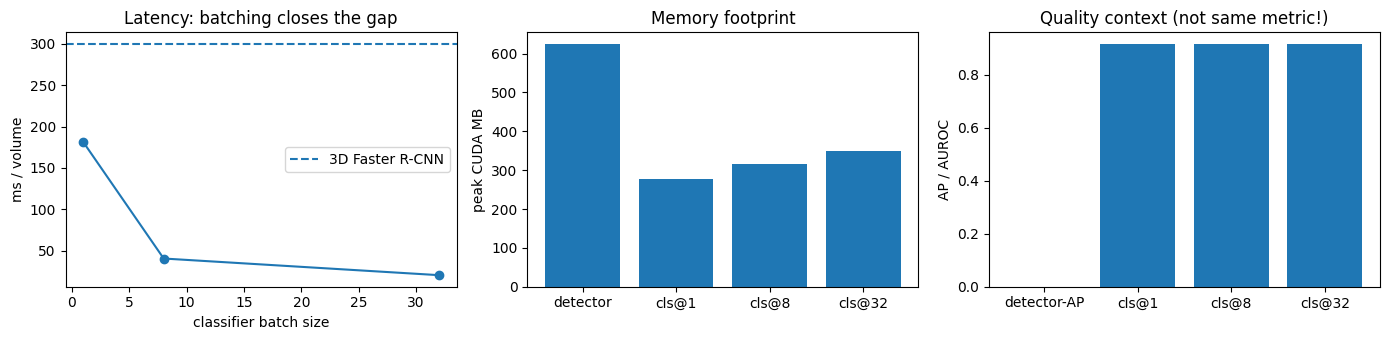

In [53]:
# Plot: latency vs batch size, memory footprint, quality context
import matplotlib.pyplot as plt
bs, ms, mem, auroc = [], [], [], []
for k,v in r['slice_classifier'].items():
    if k.startswith('batch_'):
        bs.append(int(k.split('_')[1])); ms.append(v['mean_ms_per_volume'])
        mem.append(v['peak_cuda_mb']); auroc.append(v['auroc'])
fig, ax = plt.subplots(1,3, figsize=(14,3.5))
ax[0].plot(bs, ms, marker='o'); ax[0].axhline(r['detector']['mean_ms_per_volume'], ls='--', label='3D Faster R-CNN')
ax[0].set(xlabel='classifier batch size', ylabel='ms / volume', title='Latency: batching closes the gap'); ax[0].legend()
ax[1].bar(['detector']+[f'cls@{b}' for b in bs], [r['detector']['peak_cuda_mb']]+mem)
ax[1].set(ylabel='peak CUDA MB', title='Memory footprint')
ax[2].bar(['detector-AP']+[f'cls@{b}' for b in bs], [r['detector']['ap_iou03']]+auroc)
ax[2].set(ylabel='AP / AUROC', title='Quality context (not same metric!)'); plt.tight_layout(); plt.show()

## 6. Profiling — where do latency and memory come from?

The benchmark above gives end-to-end results; this section explains them. It profiles one representative held-out volume in two complementary ways:

1. **Stage attribution:** detector backbone 3D convolutions, RPN convolutions, anchor generation, proposal decode/top-k, RPN 3D NMS, RoI pooling, box heads, and final NMS/copy. The classifier is split into slice preparation/H2D, 2D CNN, and sigmoid/D2H.
2. **Operator attribution:** `torch.profiler` ranks individual convolution, pooling, sorting, copying, and other operators by GPU/CPU time.

The normal benchmark remains the canonical latency number. Stage profiling synchronizes after each stage to attribute work, so its stage sum contains extra synchronization overhead.

[profile] modiface v0.9.0 | cwd=/content/drive/MyDrive/Colab Notebooks/modiface
[profile] device=cuda
[data] root=/content/drive/MyDrive/Colab Notebooks/modiface/data/cads
[data] seg parts=[551] labels={'0003_kits21': [2, 3], '0004_lits': [5]}
[data] real cohort: 30 volumes
[data] split train/val/test = 24/3/3
[ckpt] loaded checkpoints/faster_rcnn_3d.pt
[ckpt] loaded checkpoints/slice_classifier.pt
/usr/local/lib/python3.13/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(
[profile] canonical end-to-end: detector=257.6ms, classifier=20.8ms
[profile] detector stage attribution:
  backbone_3d_convs              175.74ms ( 67.7%) incremental_peak=335.5MB
  rpn_3d_convs_and_heads          11.04ms (  4.3%) incremental_peak=8.4MB
  anchor_generation                0.98ms (  0.4%) incremental_peak=0.5MB
  proposa

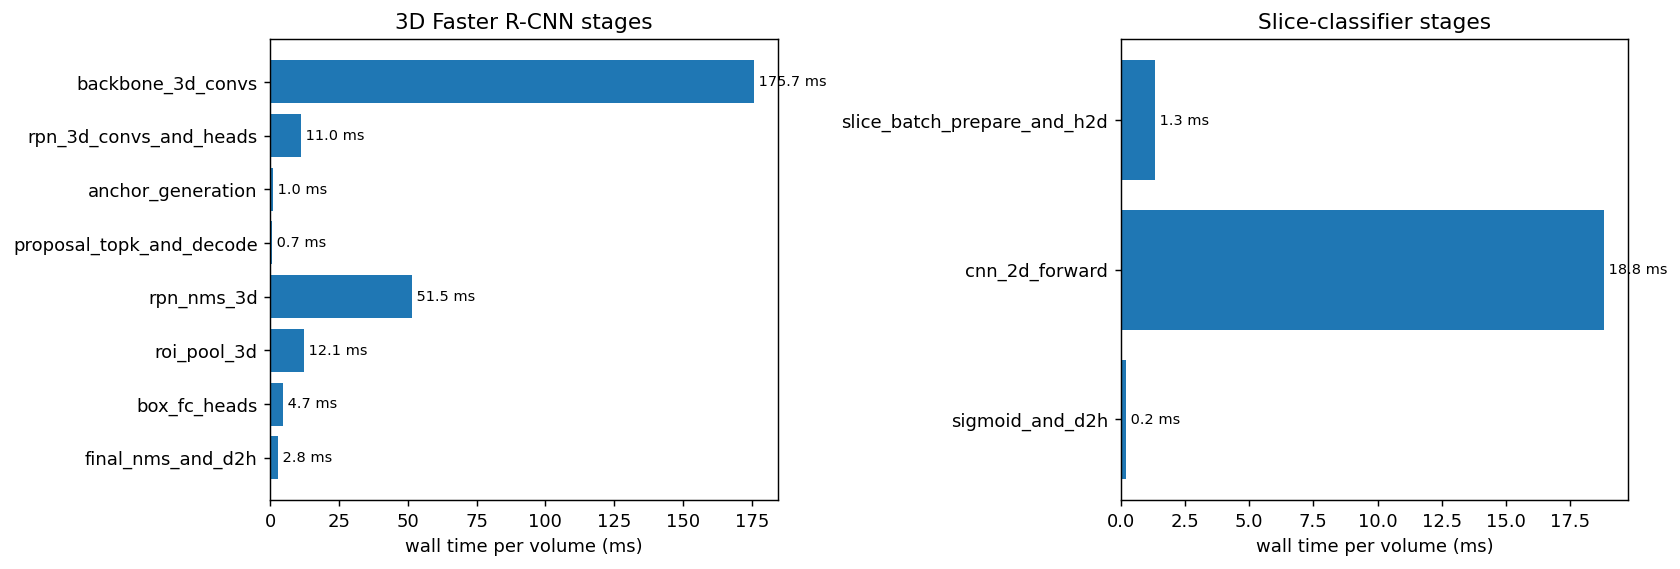

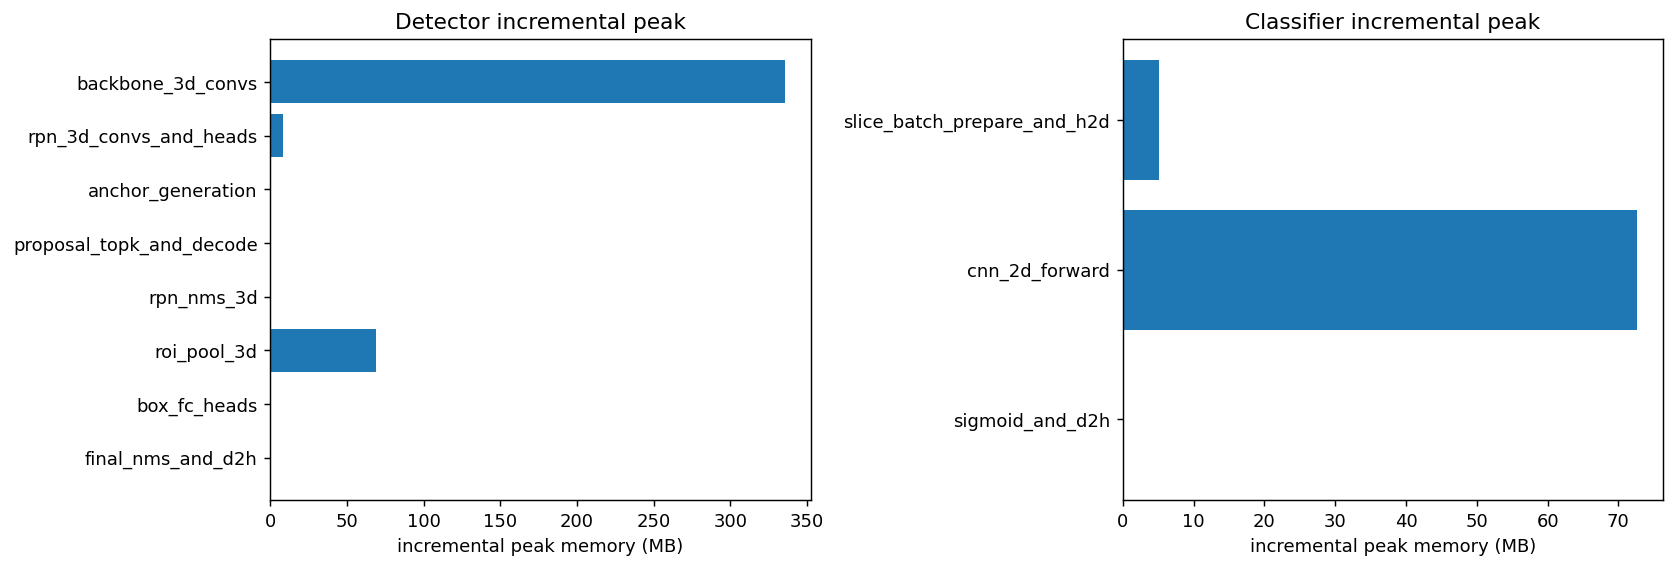

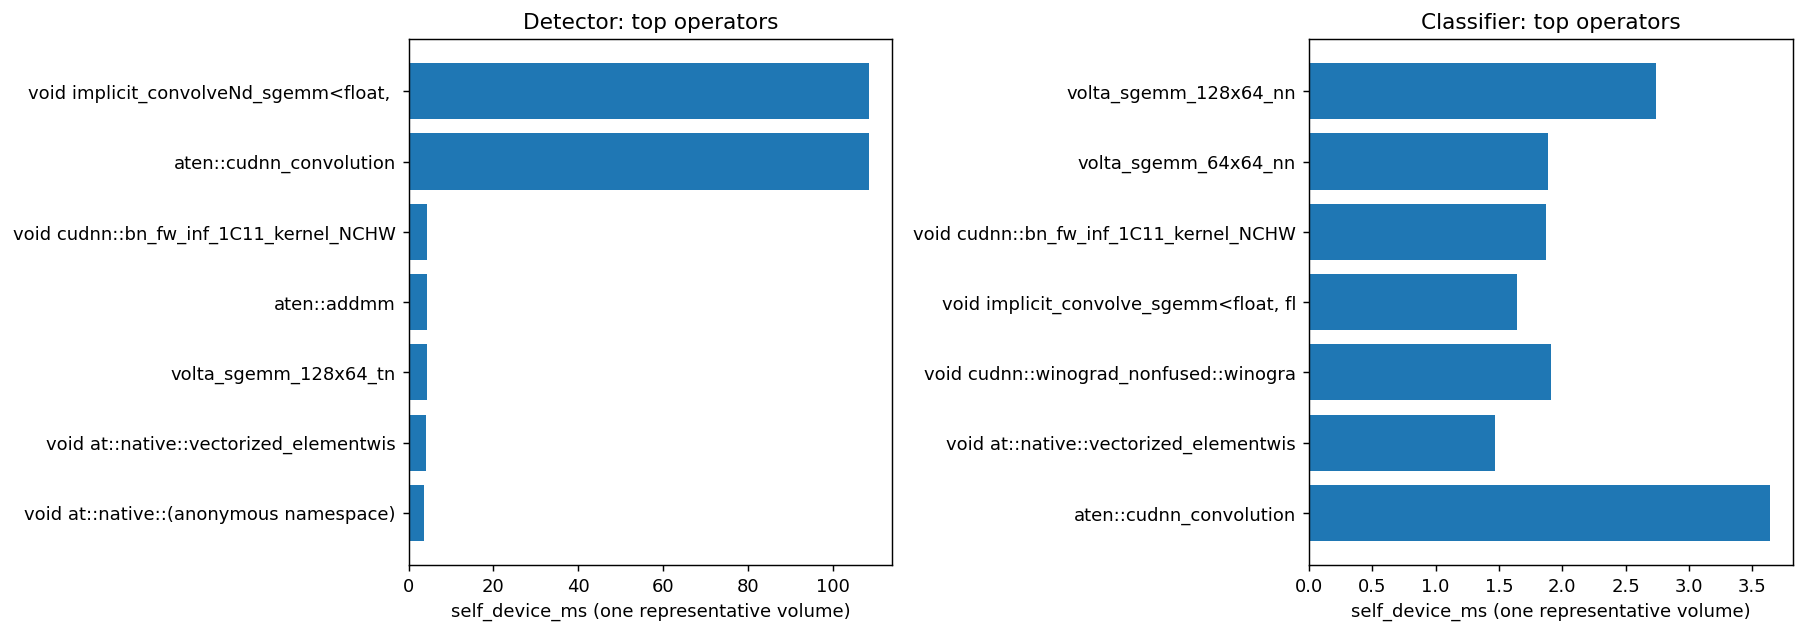

In [54]:
!python scripts/profile_models.py --config configs/config.yaml --data-root "/content/drive/MyDrive/Colab Notebooks/modiface/data/cads" --cls-batch-size 32 --warmup 3 --repeats 10 --out results

import json
from pathlib import Path
from IPython.display import Image, display

p = json.load(open('results/profile.json'))
print('\nDetector stage attribution:')
for name, row in p['detector']['stages'].items():
    print(f"  {name:28s} {row['mean_ms']:8.2f} ms  "
          f"{row['percent_of_stage_sum']:5.1f}%  "
          f"incremental peak {row['incremental_peak_mb']:.1f} MB")

print('\nTop detector operators:')
for row in p['operators']['detector'][:10]:
    metric = row['self_device_ms'] if p['device'].startswith('cuda') else row['self_cpu_ms']
    print(f"  {row['operator'][:45]:45s} {metric:8.2f} ms  calls={row['calls']}")

for f in ['profile_stage_latency.png', 'profile_stage_memory.png', 'profile_top_operators.png']:
    display(Image(str(Path('results') / f)))

### How to interpret the profile

- If `backbone_3d_convs` or `rpn_3d_convs_and_heads` dominates, 3D feature maps and kernels are the main latency/memory cost. Their compute grows with the full `D × H × W` volume rather than one 2D slice batch.
- If `rpn_nms_3d` or `final_nms_and_d2h` dominates, proposal count and the serial Python 3D-NMS loop are the bottleneck; lower `rpn_pre_nms` / `rpn_post_nms` or use a vectorized/compiled NMS.
- If `roi_pool_3d` dominates, too many proposals are being cropped and pooled one by one; reduce the post-NMS proposal budget or replace the loop with batched 3D RoIAlign.
- `incremental_peak_mb` identifies which stage creates the largest temporary allocation. `allocated_after_mb` (available in `profile.json`) shows memory still retained after that stage.
- The current RPN calls its shared 3D convolution twice—once for classification and again for regression. If `rpn_3d_convs_and_heads` is large, caching that shared feature is an immediate optimization candidate.

Under a tight memory budget, compare **latency at similar peak memory**, not just each model's fastest setting. For example, reduce classifier batch size until its peak memory is below the budget, then compare that latency with the detector—which cannot stream depth slices without changing its 3D architecture.